In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [ ]:
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")

training_set = dataset_train.iloc[:, 1:2].values   # Open price

In [ ]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
model = Sequential()

model.add(SimpleRNN(units=50, activation='tanh', input_shape=(X_train.shape[1], 1)))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0852
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.7749e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.7787e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.6150e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.3693e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.3437e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1333e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.6726e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.3055e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.2229e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.2310e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4230e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3797e-04
Epoch 15/20
38/38 ━━━━━

In [ ]:
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")
real_stock_price = dataset_test.iloc[:, 1:2].values

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)

inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [ ]:
X_test = []

for i in range(60, 60 + len(dataset_test)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


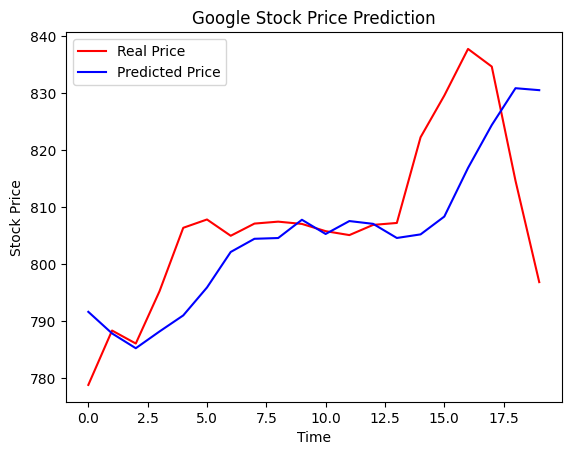

In [ ]:
plt.plot(real_stock_price, color='red', label='Real Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()